# SVD 실습

In [81]:
import numpy as np

In [57]:
# 간단한 행렬 생성
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12]
])  # 4 × 3 행렬

In [58]:
A.shape

(4, 3)

In [59]:
U, s, VT = np.linalg.svd(A, full_matrices=False)
# np.linalg.svd : SVD를 파이썬에서 바로 해주는 함수 (행렬을 U, Σ, Vᵀ로 쪼개는 함수 )
# linalg:선형계수 svd:행렬 곱

In [60]:
U

array([[-0.14087668, -0.82471435,  0.53819245],
       [-0.34394629, -0.42626394, -0.64176525],
       [-0.54701591, -0.02781353, -0.33104685],
       [-0.75008553,  0.37063688,  0.43461965]])

In [61]:
U.shape

(4, 3)

In [62]:
s #특이값 큰값부터 나옴 2.5 1.2 까지만 유의미

array([2.54624074e+01, 1.29066168e+00, 1.47968026e-15])

In [63]:
s.shape # 1차원

(3,)

In [64]:
VT

array([[-0.50453315, -0.5745157 , -0.64449826],
       [ 0.76077568,  0.05714052, -0.64649464],
       [-0.40824829,  0.81649658, -0.40824829]])

In [65]:
VT.shape

(3, 3)

In [66]:
S = np.diag(s) #diag 대각 행렬

In [67]:
S

array([[2.54624074e+01, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.29066168e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.47968026e-15]])

In [68]:
A = U @ S @ VT #행렬의 곱은 @
# A에 SDT 한 값을 다시 복원시킴

In [69]:
print("복원 행렬 A:")
print(A)
print(f"Shape: {A.shape}")

복원 행렬 A:
[[ 1.  2.  3.]
 [ 4.  5.  6.]
 [ 7.  8.  9.]
 [10. 11. 12.]]
Shape: (4, 3)


In [70]:
U[:,:2] # 4 x 2

array([[-0.14087668, -0.82471435],
       [-0.34394629, -0.42626394],
       [-0.54701591, -0.02781353],
       [-0.75008553,  0.37063688]])

In [71]:
np.diag(s[:2]) # 2 x 2

array([[25.46240744,  0.        ],
       [ 0.        ,  1.29066168]])

In [35]:
VT[:2,:] # 2 x 3

array([[-0.50453315, -0.5745157 , -0.64449826],
       [ 0.76077568,  0.05714052, -0.64649464]])

In [72]:
U[:,:2] @ np.diag(s[:2]) @ VT[:2,:]

array([[ 1.,  2.,  3.],
       [ 4.,  5.,  6.],
       [ 7.,  8.,  9.],
       [10., 11., 12.]])

# 이미지 압축 실습

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 자신의 이미지 파일 경로 사용
img = np.array(Image.open('0163.jpg').convert('L')) 
# jpg가 numpy.array로 바뀌고 이걸 img에 저장함

In [73]:
img.shape

(1879, 3072)

In [74]:
# SVD 분해
U, s, VT = np.linalg.svd(img, full_matrices=False)
print(f"특잇값 개수: {len(s)}")

특잇값 개수: 1879


In [83]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'   # 맥 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 깨지는 거 방지

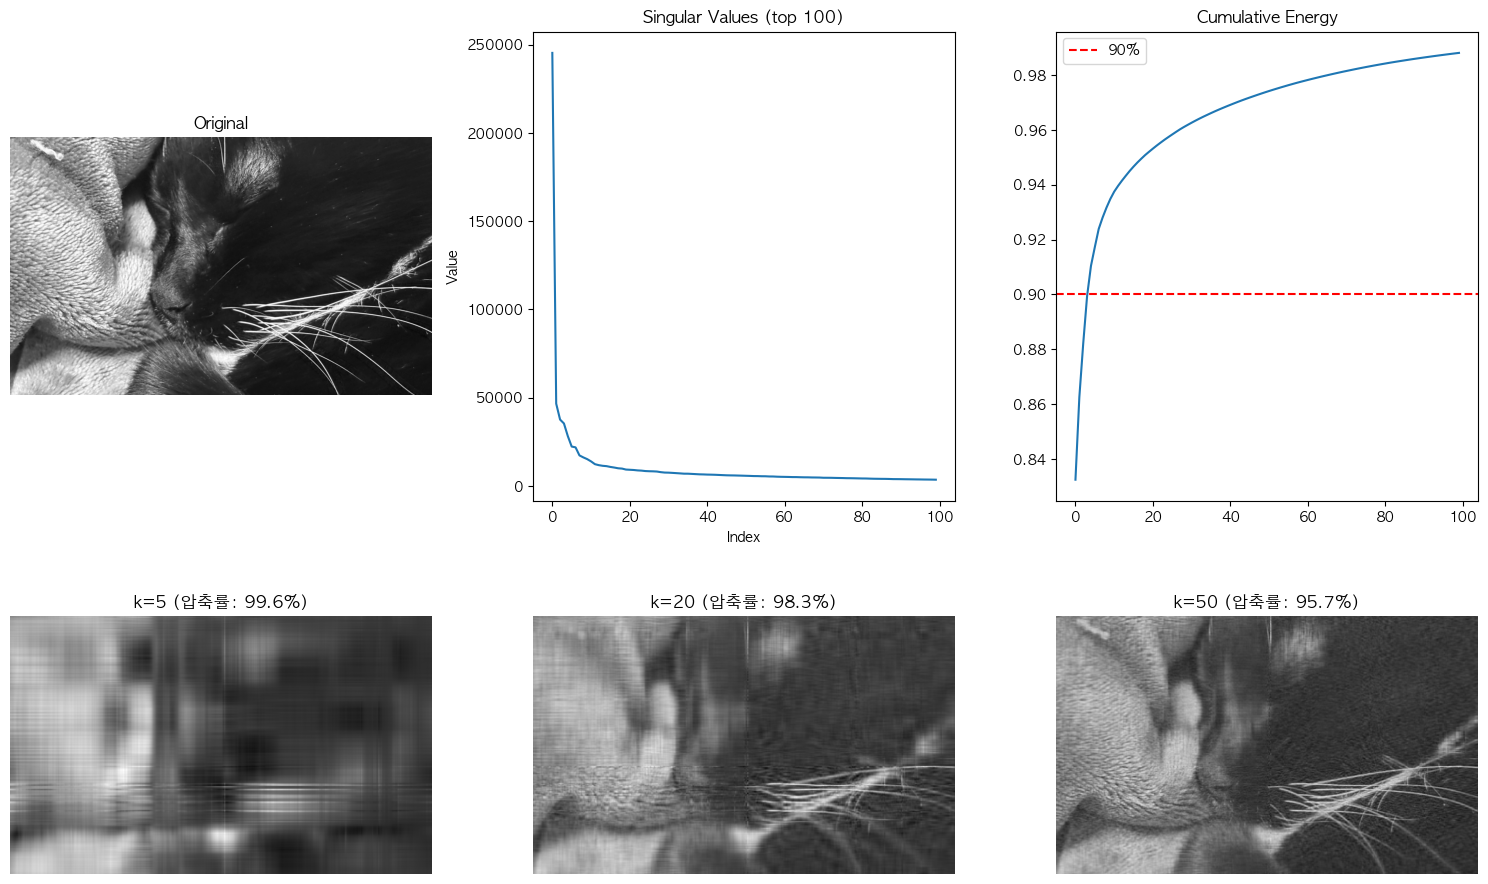

In [82]:
# 다양한 k 값으로 압축
k_values = [5, 20, 50]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')
# 특잇값 그래프
axes[0, 1].plot(s[:100])
axes[0, 1].set_title('Singular Values (top 100)')
axes[0, 1].set_xlabel('Index')
axes[0, 1].set_ylabel('Value')

# 누적 에너지
cumsum = np.cumsum(s**2) / np.sum(s**2)
axes[0, 2].plot(cumsum[:100])
axes[0, 2].set_title('Cumulative Energy')
axes[0, 2].axhline(y=0.9, color='r', linestyle='--', label='90%')
axes[0, 2].legend()

for idx, k in enumerate(k_values):
    # k개 특잇값으로 재구성
    img_compressed = U[:, :k] @ np.diag(s[:k]) @ VT[:k, :]
    
    # 압축률 계산
    original_size = img.shape[0] * img.shape[1]
    compressed_size = k * (img.shape[0] + img.shape[1] + 1)
    ratio = (1 - compressed_size / original_size) * 100
    
    # 시각화
    row = 1 + idx // 3
    col = idx % 3
    axes[row, col].imshow(img_compressed, cmap='gray')
    axes[row, col].set_title(f'k={k} (압축률: {ratio:.1f}%)')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [54]:
# 정보 보존률 계산
for k in k_values:
    energy = np.sum(s[:k]**2) / np.sum(s**2) * 100
    print(f"k={k}: 정보 보존률 {energy:.1f}%")

k=5: 정보 보존률 91.0%
k=20: 정보 보존률 95.2%
k=50: 정보 보존률 97.4%
k=100: 정보 보존률 98.8%
